# Método de Hartree-Fock-Roothaan — Átomo de Helio
## Visualización de la convergencia SCF

Este notebook lee los datos exportados por el programa Fortran `HEHFR.f90`  
y grafica la convergencia del ciclo de autoconsistencia (SCF).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Estilo general
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120
})

## 1. Cargar los datos

In [2]:
df = pd.read_csv('convergencia_scf.csv')
print(f'Iteraciones totales: {len(df)}')
print(f'Energía final      : {df["energia_ua"].iloc[-1]:.9f} u.a.')
print(f'Valor experimental : -2.903000000 u.a.')
print(f'Error relativo     : {abs(df["energia_ua"].iloc[-1] - (-2.903)) / 2.903 * 100:.4f} %')
df.head(10)

Iteraciones totales: 18
Energía final      : -2.568719758 u.a.
Valor experimental : -2.903000000 u.a.
Error relativo     : 11.5150 %


,iteracion,energia_ua,delta_energia,eigenvalor1
0,1,-3.536837,3.536837,-1.719243
1,2,-2.497981,1.038855,-0.759607
2,3,-2.584115,0.086134,-0.823894
3,4,-2.565475,0.018640,-0.809676
4,5,-2.569409,0.003934,-0.812663
5,6,-2.568574,0.000835,-0.812028
6,7,-2.568751,0.000177,-0.812163
7,8,-2.568713,0.000038,-0.812134
8,9,-2.568721,0.000008,-0.812140
9,10,-2.568719,0.000002,-0.812139


## 2. Convergencia de la energía total

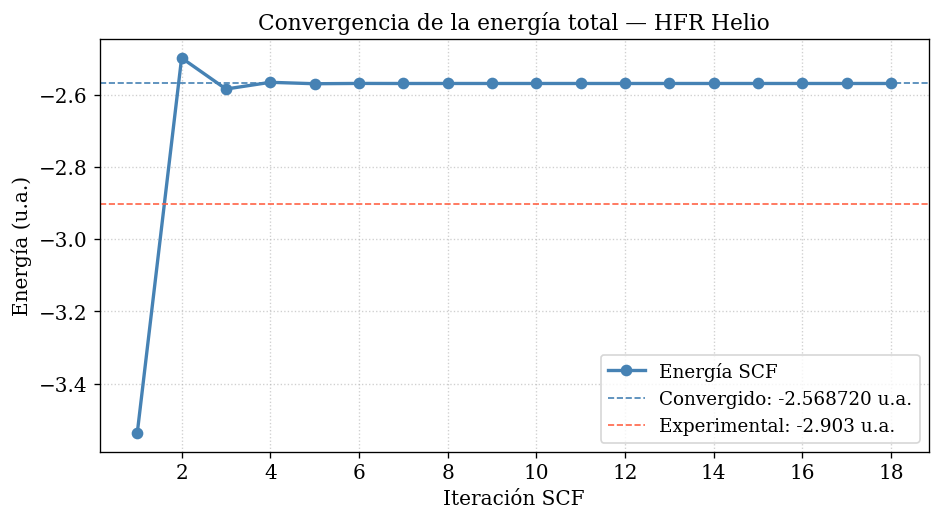

Figura guardada: convergencia_energia.png


In [4]:
E_final = df['energia_ua'].iloc[-1]
E_exp   = -2.903  # valor experimental

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(df['iteracion'], df['energia_ua'],
        'o-', color='steelblue', linewidth=2, markersize=6, label='Energía SCF')

ax.axhline(E_final, color='steelblue', linestyle='--', linewidth=1,
           label=f'Convergido: {E_final:.6f} u.a.')
ax.axhline(E_exp, color='tomato', linestyle='--', linewidth=1,
           label=f'Experimental: {E_exp:.3f} u.a.')

ax.set_xlabel('Iteración SCF')
ax.set_ylabel('Energía (u.a.)')
ax.set_title('Convergencia de la energía total — HFR Helio')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('convergencia_energia.png', dpi=150)
plt.show()
print('Figura guardada: convergencia_energia.png')

## 3. Convergencia del delta de energía (escala logarítmica)

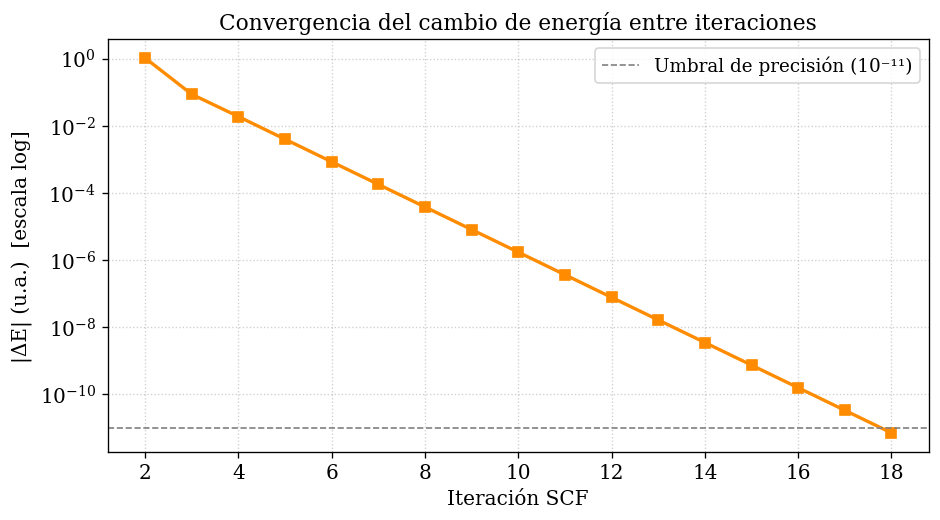

Figura guardada: convergencia_delta.png


In [5]:
# Excluir la primera iteracion (delta = |0 - E_0| puede ser grande)
df_delta = df[df['iteracion'] > 1].copy()

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.semilogy(df_delta['iteracion'], df_delta['delta_energia'],
            's-', color='darkorange', linewidth=2, markersize=6)

ax.axhline(1e-11, color='gray', linestyle='--', linewidth=1,
           label='Umbral de precisión (10⁻¹¹)')

ax.set_xlabel('Iteración SCF')
ax.set_ylabel('|ΔE| (u.a.)  [escala log]')
ax.set_title('Convergencia del cambio de energía entre iteraciones')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('convergencia_delta.png', dpi=150)
plt.show()
print('Figura guardada: convergencia_delta.png')

## 4. Evolución del eigenvalor más bajo (E')

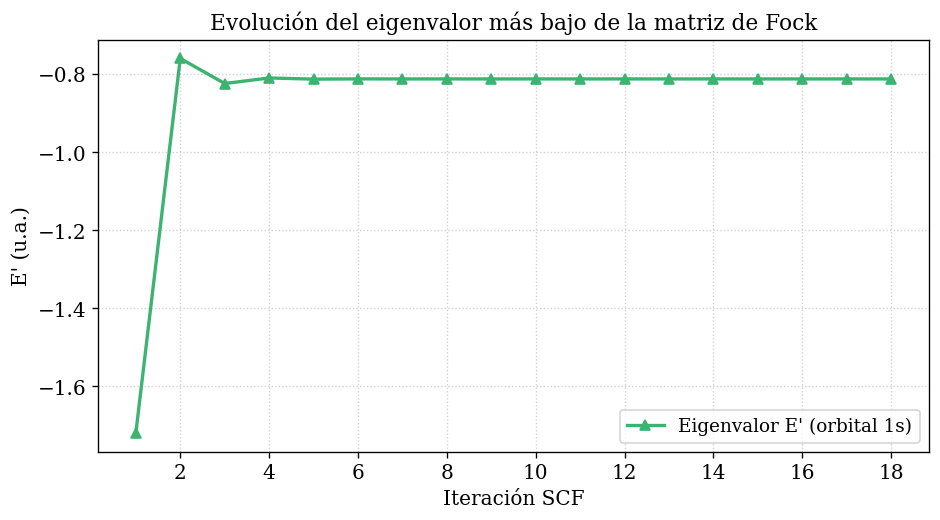

Figura guardada: convergencia_eigenvalor.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(df['iteracion'], df['eigenvalor1'],
        '^-', color='mediumseagreen', linewidth=2, markersize=6,
        label="Eigenvalor E' (orbital 1s)")

ax.set_xlabel('Iteración SCF')
ax.set_ylabel("E' (u.a.)")
ax.set_title("Evolución del eigenvalor más bajo de la matriz de Fock")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('convergencia_eigenvalor.png', dpi=150)
plt.show()
print('Figura guardada: convergencia_eigenvalor.png')

## 5. Panel resumen (3 gráficas juntas)

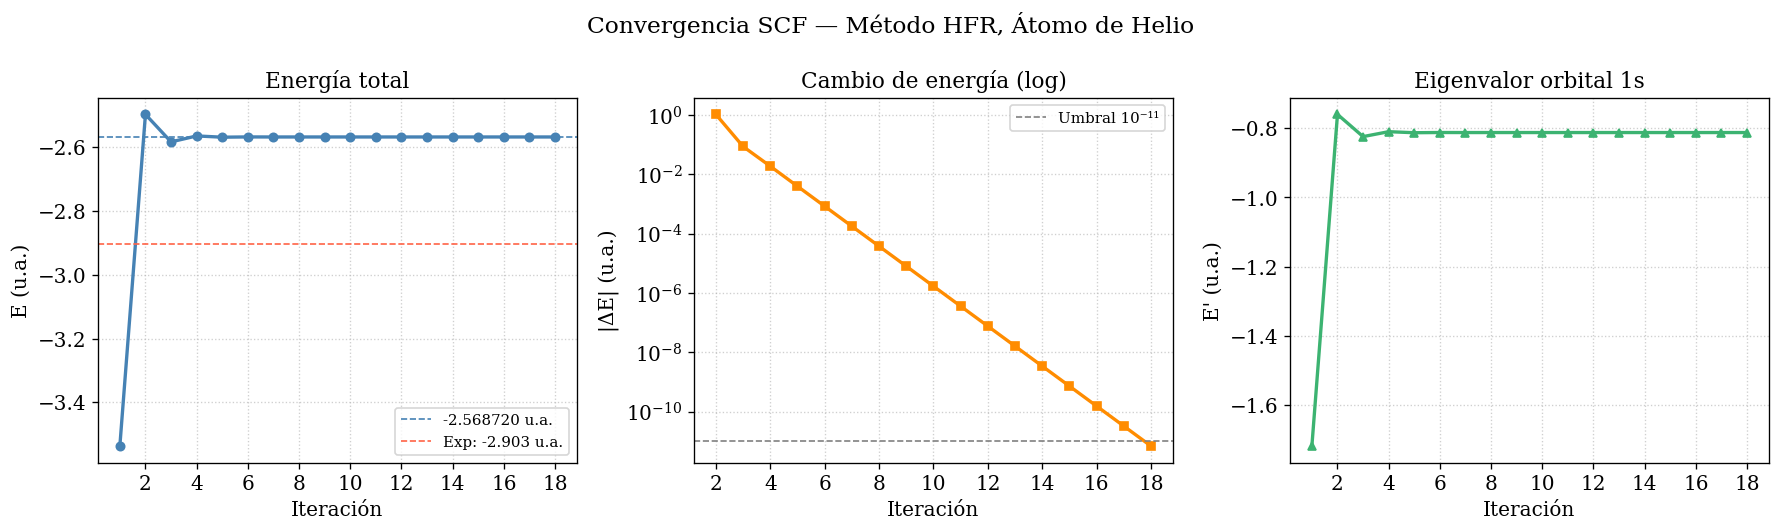

Figura guardada: panel_resumen_hfr.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Convergencia SCF — Método HFR, Átomo de Helio', fontsize=14)

# --- Panel 1: Energía ---
axes[0].plot(df['iteracion'], df['energia_ua'],
             'o-', color='steelblue', linewidth=2, markersize=5)
axes[0].axhline(E_final, color='steelblue', linestyle='--', linewidth=1,
                label=f'{E_final:.6f} u.a.')
axes[0].axhline(E_exp, color='tomato', linestyle='--', linewidth=1,
                label=f'Exp: {E_exp} u.a.')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('E (u.a.)')
axes[0].set_title('Energía total')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Panel 2: Delta E ---
axes[1].semilogy(df_delta['iteracion'], df_delta['delta_energia'],
                 's-', color='darkorange', linewidth=2, markersize=5)
axes[1].axhline(1e-11, color='gray', linestyle='--', linewidth=1,
                label='Umbral 10⁻¹¹')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('|ΔE| (u.a.)')
axes[1].set_title('Cambio de energía (log)')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', linestyle=':', alpha=0.6)
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Panel 3: Eigenvalor ---
axes[2].plot(df['iteracion'], df['eigenvalor1'],
             '^-', color='mediumseagreen', linewidth=2, markersize=5)
axes[2].set_xlabel('Iteración')
axes[2].set_ylabel("E' (u.a.)")
axes[2].set_title('Eigenvalor orbital 1s')
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('panel_resumen_hfr.png', dpi=150)
plt.show()
print('Figura guardada: panel_resumen_hfr.png')

In [10]:
E_calc = df['energia_ua'].iloc[-1]
E_exp  = -2.903

resumen = pd.DataFrame({
    'Cantidad': [
        'Energía calculada (u.a.)',
        'Energía experimental (u.a.)',
        'Error absoluto (u.a.)',
        'Error relativo (%)',
        'Iteraciones SCF',
        'Eigenvalor 1s final (u.a.)'
    ],
    'Valor': [
        f'{E_calc:.9f}',
        f'{E_exp:.9f}',
        f'{abs(E_calc - E_exp):.6f}',
        f'{abs(E_calc - E_exp) / abs(E_exp) * 100:.4f}',
        f'{len(df)}',
        f"{df['eigenvalor1'].iloc[-1]:.9f}"
    ]
})

resumen.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Cantidad,Valor
Energía calculada (u.a.),-2.568719758
Energía experimental (u.a.),-2.903000000
Error absoluto (u.a.),0.334280
Error relativo (%),11.5150
Iteraciones SCF,18
Eigenvalor 1s final (u.a.),-0.812138992
